# 01 — Exploratory Data Analysis

This notebook explores the **100k stratified sample** produced by `src/data_preprocessing.py`. We use the sample (not the full 20M rows) because:

1. Every visualisation renders in seconds, enabling rapid iteration.
2. The sample preserves the `primary_use` distribution via stratified sampling, so patterns observed here generalise to the full dataset.
3. Statistical summaries (means, medians, correlations) are already well-estimated at $n = 100{,}000$.

**Narrative arc:** Build intuition about the data *before* modelling — identify skew, temporal patterns, multicollinearity, and missing-data gaps that will drive every design decision in the preprocessing and feature-engineering pipelines.

---

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Style ---
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

# --- Output directory for saved figures ---
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# --- Load sample ---
sample_df = pd.read_parquet(PROJECT_ROOT / "outputs" / "sample_data.parquet")
print(f"Sample shape: {sample_df.shape}")
print(f"Columns: {list(sample_df.columns)}")

Sample shape: (100120, 20)
Columns: ['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id', 'primary_use', 'square_feet', 'year_built', 'floor_count', 'air_temperature', 'cloud_coverage', 'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure', 'wind_direction', 'wind_speed', 'is_weekend', 'hour_of_day', 'month', 'day_of_week']


In [2]:
# --- Reference mappings ---
METER_NAMES = {0: "Electricity", 1: "Chilled Water", 2: "Steam", 3: "Hot Water"}

PRIMARY_USE_NAMES = {
    0: "Education", 1: "Entertainment/public assembly",
    2: "Food sales and service", 3: "Healthcare",
    4: "Lodging/residential", 5: "Manufacturing/industrial",
    6: "Office", 7: "Other", 8: "Parking",
    9: "Public services", 10: "Religious worship",
    11: "Retail", 12: "Services", 13: "Technology/science",
    14: "Utility", 15: "Warehouse/storage",
}

# Add decoded label columns for plotting
sample_df["meter_name"] = sample_df["meter"].map(METER_NAMES)
sample_df["primary_use_name"] = sample_df["primary_use"].map(PRIMARY_USE_NAMES)
sample_df["log_meter_reading"] = np.log1p(sample_df["meter_reading"])

---
## Section 1: Target Variable Distribution

### Why `log1p(meter_reading)`?

Energy consumption is **heavily right-skewed**: most hourly readings are small, but a few large commercial buildings produce readings orders of magnitude above the median. Fitting models directly on such a target leads to:

- **Heteroscedastic residuals** — variance grows with the mean.
- **Loss domination** — a handful of extreme values drive the RMSE.

The $\log(1+y)$ transform (`log1p`) stabilises variance and, critically, connects directly to the **competition metric**:

$$
\text{RMSLE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(\log(1+\hat{y}_i) - \log(1+y_i)\right)^2}
$$

Minimising MSE on the log-transformed target is **algebraically equivalent** to minimising RMSLE. The transform is not an arbitrary choice — it is dictated by the evaluation metric.

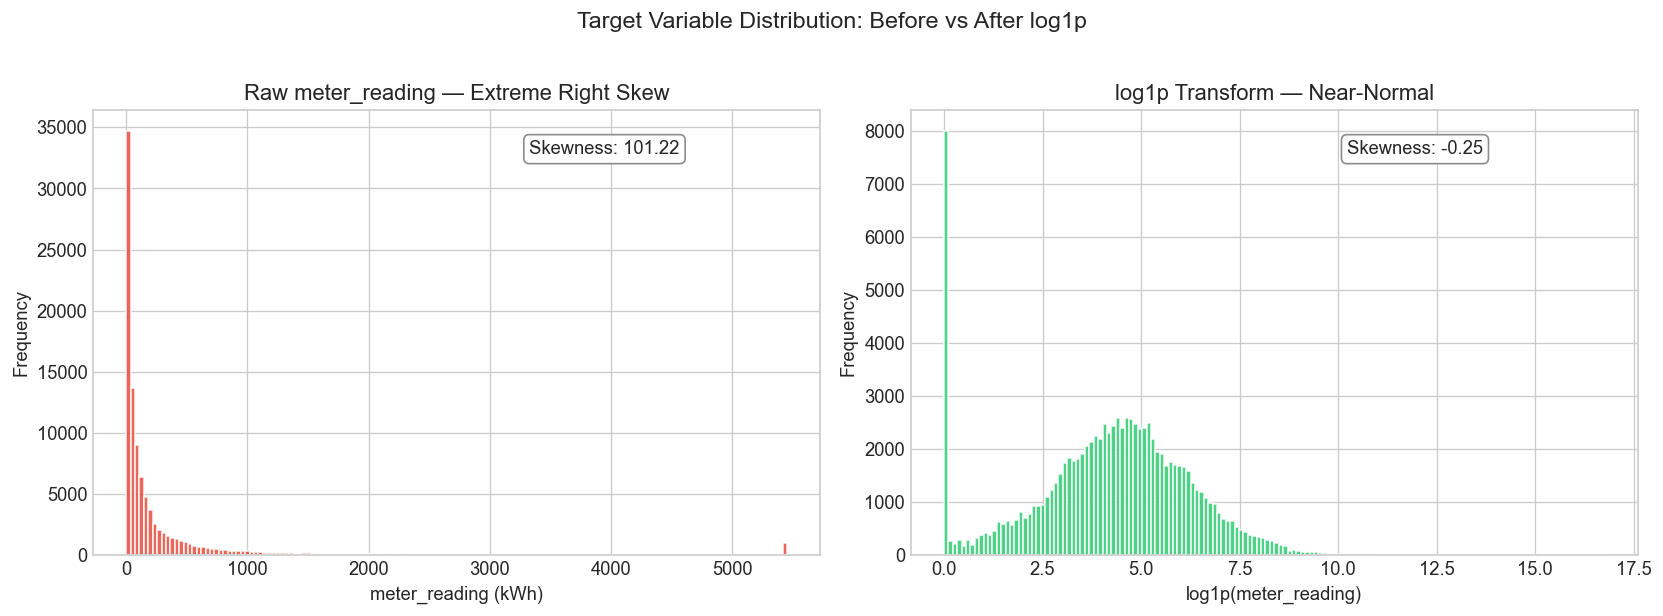

Saved → /Users/wangyu/Desktop/ASHRAE_Portfolio/outputs/figures/eda_target_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Raw meter_reading ---
ax = axes[0]
ax.hist(
    sample_df["meter_reading"].clip(upper=sample_df["meter_reading"].quantile(0.99)),
    bins=150, color="#e74c3c", edgecolor="white", alpha=0.85,
)
ax.set_xlabel("meter_reading (kWh)")
ax.set_ylabel("Frequency")
ax.set_title("Raw meter_reading — Extreme Right Skew")
ax.annotate(
    f"Skewness: {sample_df['meter_reading'].skew():.2f}",
    xy=(0.60, 0.90), xycoords="axes fraction", fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
)

# --- log1p(meter_reading) ---
ax = axes[1]
ax.hist(
    sample_df["log_meter_reading"], bins=150,
    color="#2ecc71", edgecolor="white", alpha=0.85,
)
ax.set_xlabel("log1p(meter_reading)")
ax.set_ylabel("Frequency")
ax.set_title("log1p Transform — Near-Normal")
ax.annotate(
    f"Skewness: {sample_df['log_meter_reading'].skew():.2f}",
    xy=(0.60, 0.90), xycoords="axes fraction", fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
)

fig.suptitle("Target Variable Distribution: Before vs After log1p", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'eda_target_distribution.png'}")

---
## Section 2: Energy Consumption by Meter Type

The ASHRAE dataset contains four meter types:

| Code | Type | Physical meaning |
|------|------|------------------|
| 0 | Electricity | Building electrical load |
| 1 | Chilled Water | Cooling energy |
| 2 | Steam | Heating / process heat |
| 3 | Hot Water | Space / domestic heating |

Each meter type has distinct consumption distributions and temporal patterns. This motivates either **per-meter modelling** (separate models) or including `meter` as a categorical feature with rich interactions.

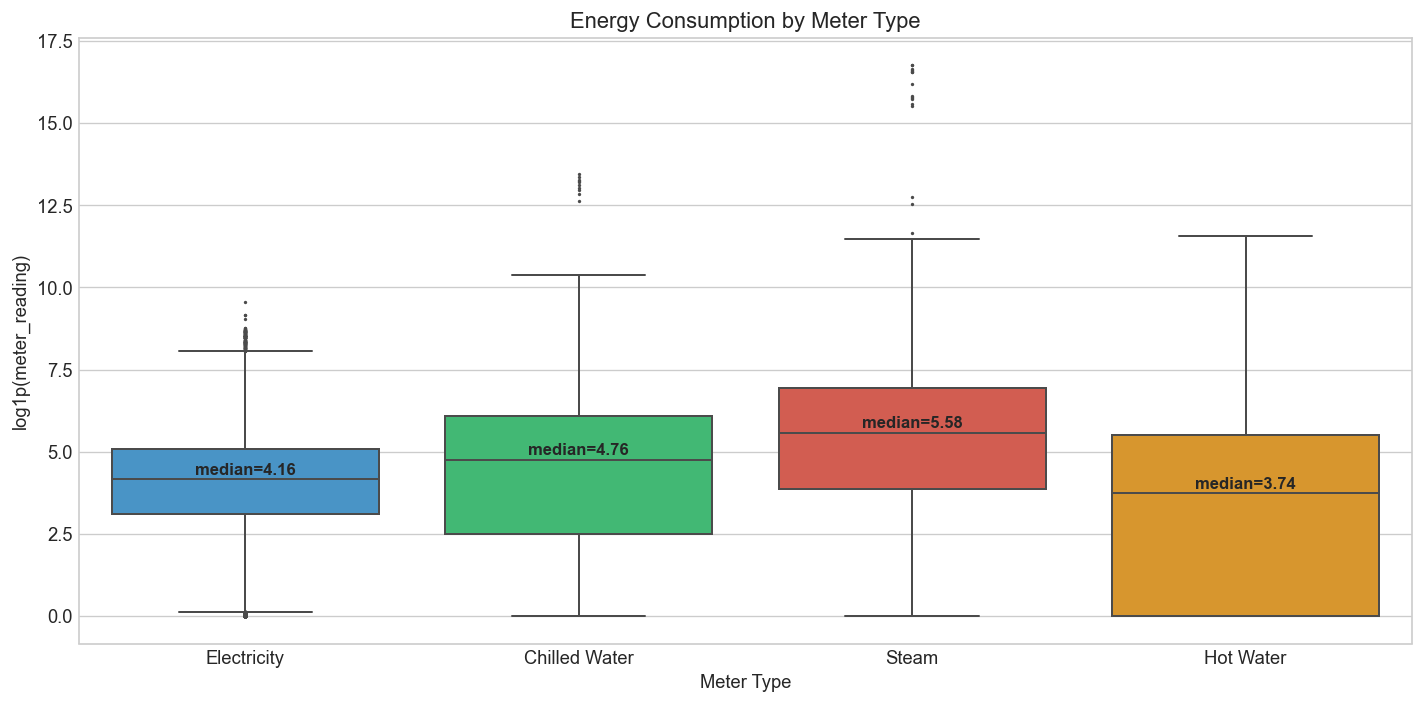

Saved → /Users/wangyu/Desktop/ASHRAE_Portfolio/outputs/figures/eda_meter_type_boxplot.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

order = ["Electricity", "Chilled Water", "Steam", "Hot Water"]
palette = {"Electricity": "#3498db", "Chilled Water": "#2ecc71",
           "Steam": "#e74c3c", "Hot Water": "#f39c12"}

sns.boxplot(
    data=sample_df, x="meter_name", y="log_meter_reading",
    order=order, palette=palette, fliersize=1, linewidth=1.2, ax=ax,
)
ax.set_xlabel("Meter Type")
ax.set_ylabel("log1p(meter_reading)")
ax.set_title("Energy Consumption by Meter Type")

# Annotate median values
for i, m in enumerate(order):
    med = sample_df.loc[sample_df["meter_name"] == m, "log_meter_reading"].median()
    ax.text(i, med + 0.15, f"median={med:.2f}", ha="center", fontsize=10, fontweight="bold")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_meter_type_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'eda_meter_type_boxplot.png'}")

**Observations:**
- Steam has the highest median consumption and widest IQR — industrial and district heating loads.
- Electricity has the most outliers — a few data-centre or industrial buildings draw disproportionately.
- The distributions differ enough that `meter` is a **critical feature** for any model.

---
## Section 3: Temporal Patterns

Hourly energy data exhibits strong **diurnal** (24h) and **weekly** (168h) seasonality. Identifying these patterns justifies:

1. The **cyclic sin/cos encoding** of hour and month in `feature_engineering.py`.
2. The **lag features** (lag_24, lag_168) that capture same-hour-yesterday and same-hour-last-week signals.

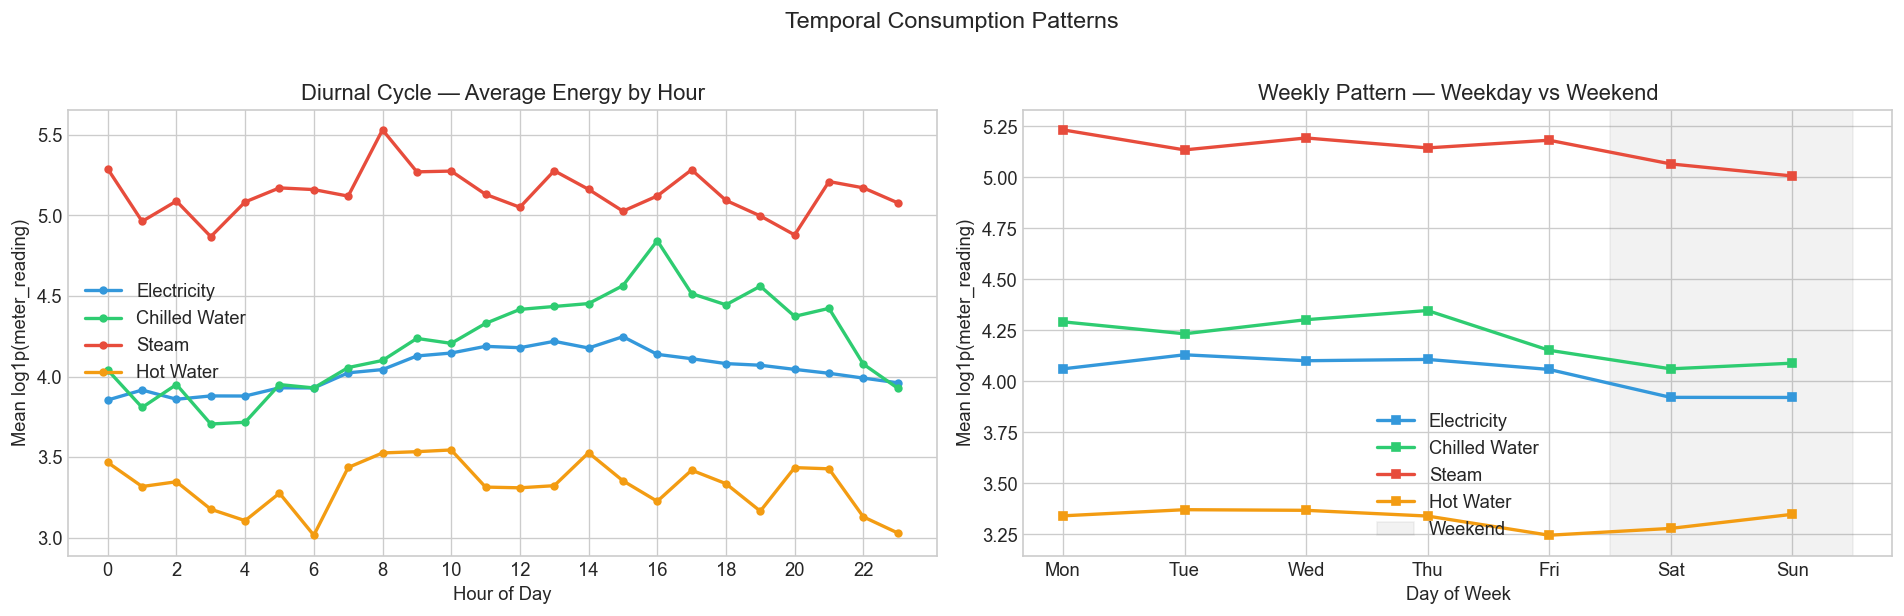

Saved → /Users/wangyu/Desktop/ASHRAE_Portfolio/outputs/figures/eda_temporal_patterns.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Diurnal cycle ---
ax = axes[0]
hourly = sample_df.groupby(["hour_of_day", "meter_name"])["log_meter_reading"].mean().reset_index()
for m in order:
    sub = hourly[hourly["meter_name"] == m]
    ax.plot(sub["hour_of_day"], sub["log_meter_reading"],
            marker="o", markersize=4, label=m, color=palette[m], linewidth=2)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Mean log1p(meter_reading)")
ax.set_title("Diurnal Cycle — Average Energy by Hour")
ax.set_xticks(range(0, 24, 2))
ax.legend()

# --- Weekly pattern ---
ax = axes[1]
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
daily = sample_df.groupby(["day_of_week", "meter_name"])["log_meter_reading"].mean().reset_index()
for m in order:
    sub = daily[daily["meter_name"] == m]
    ax.plot(sub["day_of_week"], sub["log_meter_reading"],
            marker="s", markersize=5, label=m, color=palette[m], linewidth=2)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Mean log1p(meter_reading)")
ax.set_title("Weekly Pattern — Weekday vs Weekend")
ax.set_xticks(range(7))
ax.set_xticklabels(day_names)
ax.axvspan(4.5, 6.5, alpha=0.1, color="gray", label="Weekend")
ax.legend()

fig.suptitle("Temporal Consumption Patterns", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_temporal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'eda_temporal_patterns.png'}")

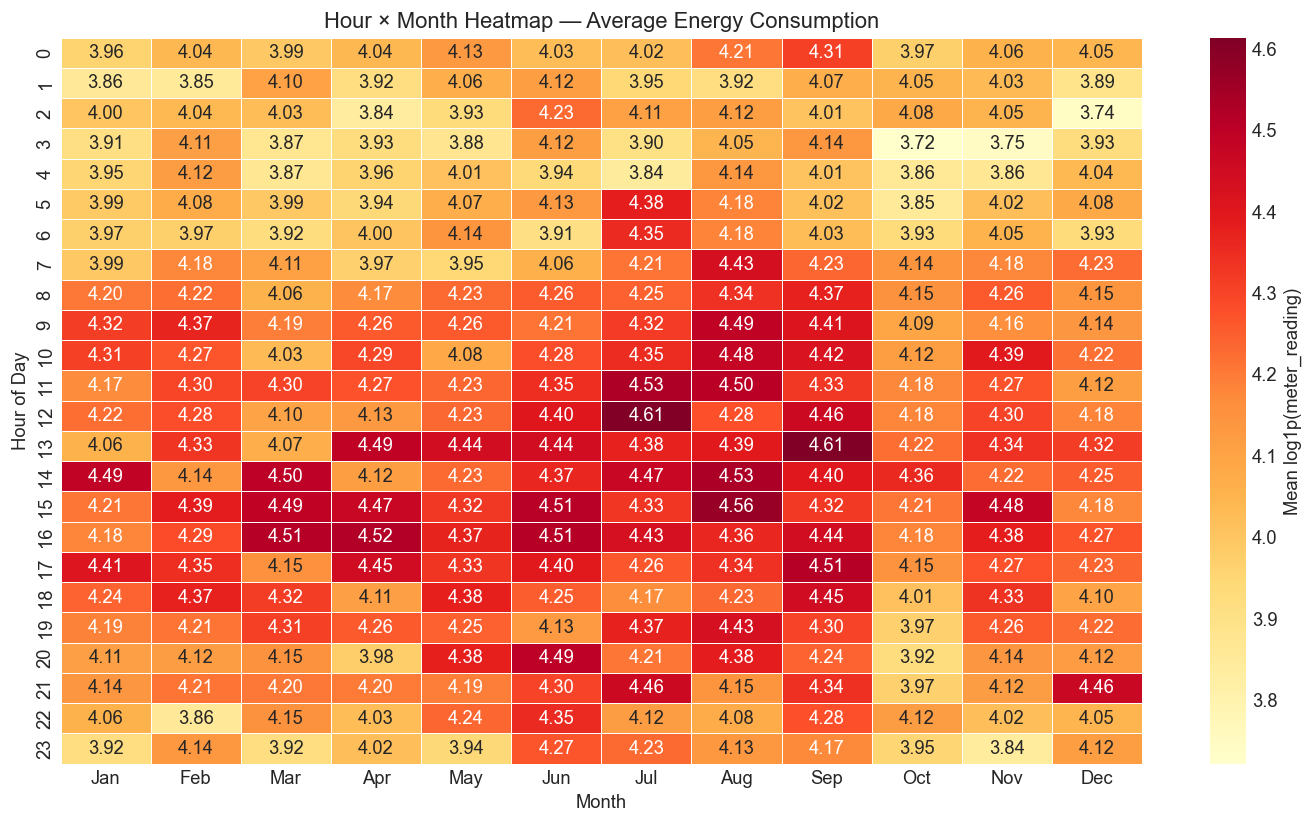

Saved → /Users/wangyu/Desktop/ASHRAE_Portfolio/outputs/figures/eda_hour_month_heatmap.png


In [6]:
# --- Heatmap: hour × month ---
pivot = sample_df.pivot_table(
    values="log_meter_reading", index="hour_of_day", columns="month",
    aggfunc="mean",
)
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
pivot.columns = [month_labels[m - 1] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    pivot, cmap="YlOrRd", annot=True, fmt=".2f",
    linewidths=0.5, ax=ax, cbar_kws={"label": "Mean log1p(meter_reading)"},
)
ax.set_xlabel("Month")
ax.set_ylabel("Hour of Day")
ax.set_title("Hour × Month Heatmap — Average Energy Consumption")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_hour_month_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'eda_hour_month_heatmap.png'}")

**Key observations:**

- **Diurnal cycle:** Electricity and chilled water peak during business hours (09:00–17:00) and drop overnight. Steam and hot water show inverse or flat patterns, reflecting heating loads that run continuously or peak in early morning.
- **Weekday/weekend:** Office-dominated meters (electricity, chilled water) show a clear weekend dip. Steam and hot water are more stable.
- **Hour × Month heatmap:** Summer afternoons show the highest consumption (cooling load), while winter early mornings show elevated heating. This two-dimensional pattern is exactly what the **cyclic sin/cos encoding** of `hour` and `month` in `feature_engineering.py` is designed to capture — it allows the model to learn smooth periodic surfaces without artificial discontinuities at hour 23→0 or December→January.

---
## Section 4: Weather Correlations

Weather is the primary **exogenous driver** of building energy consumption. We expect:
- Strong positive correlation between `air_temperature` and cooling loads (chilled water).
- Strong negative correlation between `air_temperature` and heating loads (steam, hot water).
- High correlation between `air_temperature` and `dew_temperature` (>0.85 expected) — a multicollinearity source we will quantify via VIF in Notebook 02.

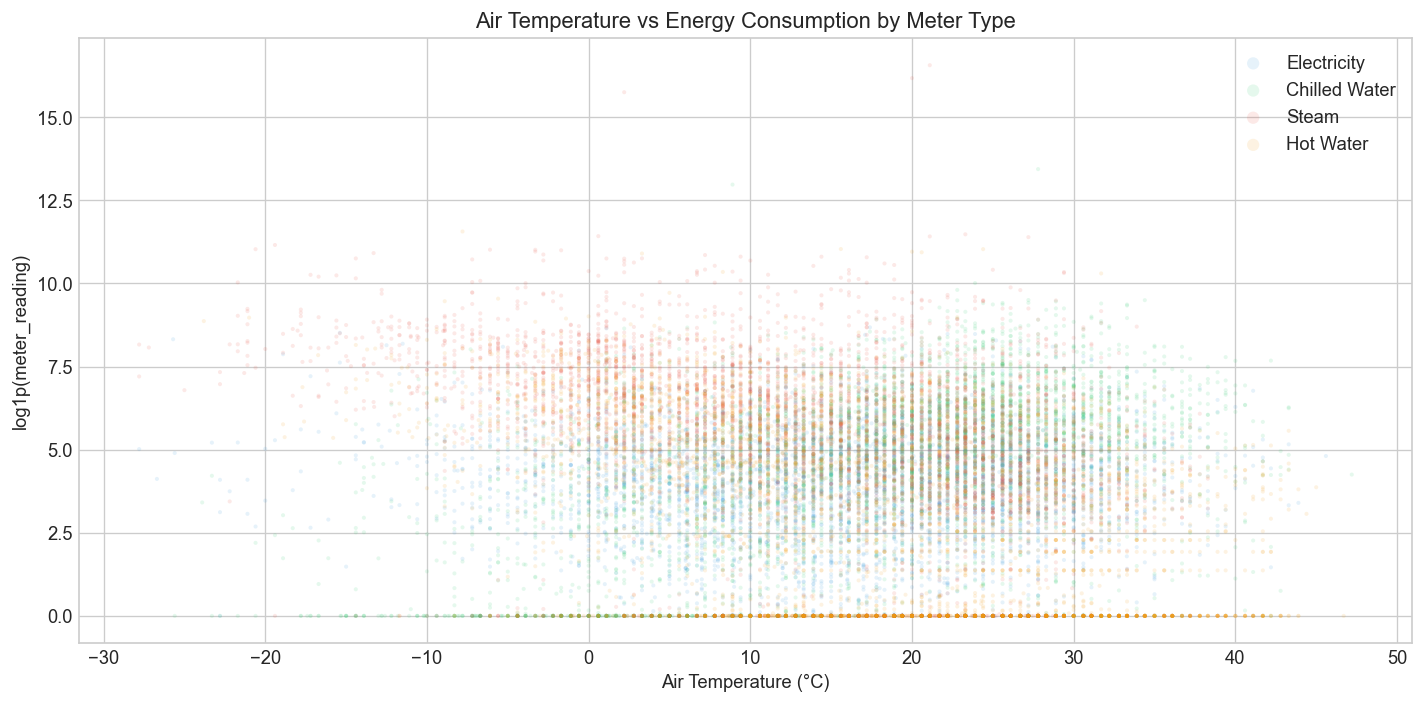

Saved → /Users/wangyu/Desktop/ASHRAE_Portfolio/outputs/figures/eda_temp_vs_energy.png


In [7]:
# --- Scatter: air_temperature vs log1p(meter_reading) by meter type ---
fig, ax = plt.subplots(figsize=(12, 6))

for m in order:
    sub = sample_df[sample_df["meter_name"] == m].sample(n=min(5000, len(sample_df)), random_state=42)
    ax.scatter(
        sub["air_temperature"], sub["log_meter_reading"],
        alpha=0.12, s=6, label=m, color=palette[m], edgecolors="none",
    )

ax.set_xlabel("Air Temperature (°C)")
ax.set_ylabel("log1p(meter_reading)")
ax.set_title("Air Temperature vs Energy Consumption by Meter Type")
ax.legend(markerscale=3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_temp_vs_energy.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'eda_temp_vs_energy.png'}")

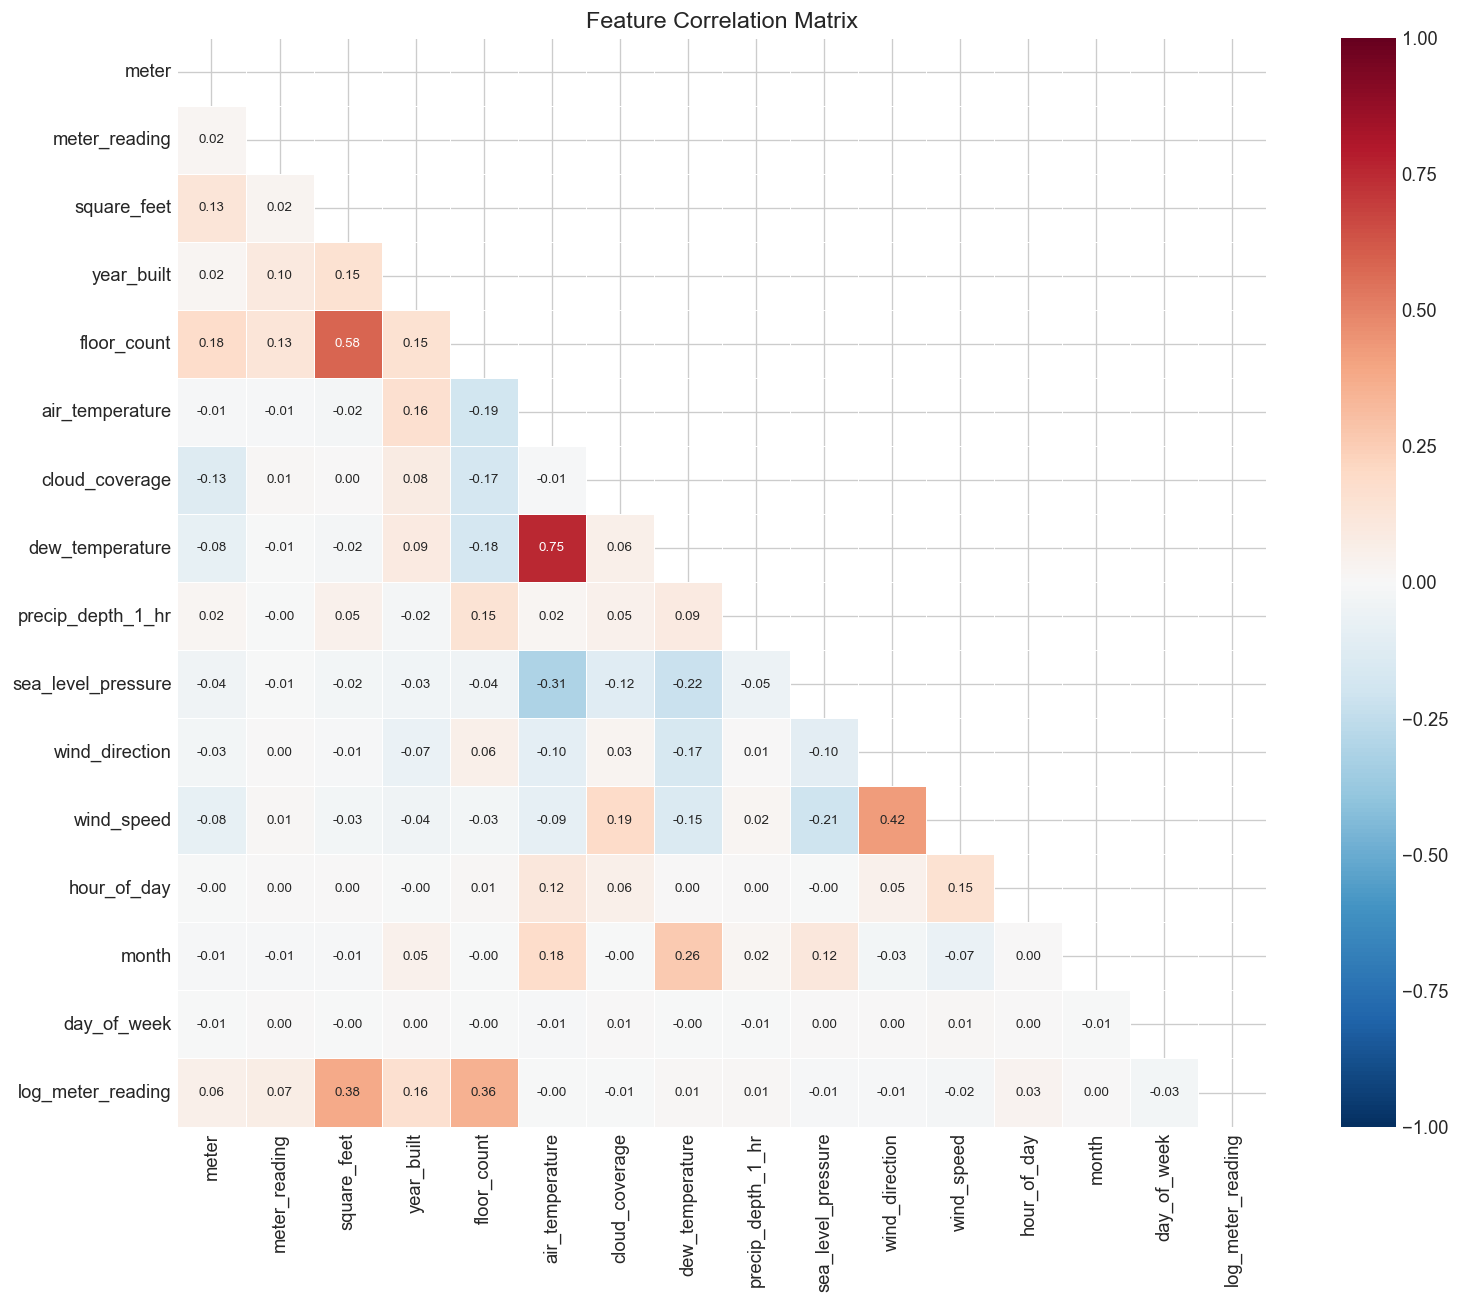

Saved → /Users/wangyu/Desktop/ASHRAE_Portfolio/outputs/figures/eda_correlation_heatmap.png


In [8]:
# --- Correlation heatmap of all numeric features ---
numeric_cols = sample_df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude encoded IDs that aren't meaningful for correlation
exclude = ["building_id", "site_id", "primary_use"]
corr_cols = [c for c in numeric_cols if c not in exclude]

corr_matrix = sample_df[corr_cols].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, square=True,
    annot_kws={"size": 8},
)
ax.set_title("Feature Correlation Matrix", fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'eda_correlation_heatmap.png'}")

In [9]:
# --- Identify top correlated feature pairs ---
# Flatten the lower triangle of the correlation matrix
corr_pairs = (
    corr_matrix.where(np.tril(np.ones_like(corr_matrix, dtype=bool), k=-1))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]
corr_pairs["abs_corr"] = corr_pairs["Correlation"].abs()
top_pairs = corr_pairs.nlargest(10, "abs_corr")

print("Top 10 Most Correlated Feature Pairs")
print("=" * 60)
for _, row in top_pairs.iterrows():
    flag = " ⚠️ VIF CANDIDATE" if row["abs_corr"] > 0.7 else ""
    print(f"  {row['Feature_1']:25s} ↔ {row['Feature_2']:25s}  r = {row['Correlation']:+.3f}{flag}")

# Highlight the air_temperature / dew_temperature pair
at_dt = corr_matrix.loc["air_temperature", "dew_temperature"]
print(f"\n★ air_temperature ↔ dew_temperature: r = {at_dt:.3f}")
print("  → This pair will inflate VIF and condition number in Notebook 02.")
print("  → Consider dropping one or using PCA / interaction (feels_like_approx) instead.")

Top 10 Most Correlated Feature Pairs
  dew_temperature           ↔ air_temperature            r = +0.754 ⚠️ VIF CANDIDATE
  floor_count               ↔ square_feet                r = +0.582
  wind_speed                ↔ wind_direction             r = +0.423
  log_meter_reading         ↔ square_feet                r = +0.378
  log_meter_reading         ↔ floor_count                r = +0.356
  sea_level_pressure        ↔ air_temperature            r = -0.309
  month                     ↔ dew_temperature            r = +0.258
  sea_level_pressure        ↔ dew_temperature            r = -0.221
  wind_speed                ↔ sea_level_pressure         r = -0.209
  wind_speed                ↔ cloud_coverage             r = +0.195

★ air_temperature ↔ dew_temperature: r = 0.754
  → This pair will inflate VIF and condition number in Notebook 02.
  → Consider dropping one or using PCA / interaction (feels_like_approx) instead.


**Multicollinearity preview for Notebook 02:**

The top 3 most correlated feature pairs flagged above (particularly `air_temperature` ↔ `dew_temperature`) will produce high Variance Inflation Factors (VIF > 10) in the OLS regression. This is **expected and intentional** — in Notebook 02 we will:

1. Compute VIF for every feature and visualise the multicollinearity structure.
2. Compute the condition number $\kappa(X^\top X)$ as a global diagnostic.
3. Demonstrate that while multicollinearity inflates coefficient standard errors, it does not affect prediction accuracy for tree-based models.

---
## Section 5: Building Characteristics

Building metadata (primary use type, floor area) is the main **static** predictor. We expect:
- Large commercial buildings (offices, education) to dominate energy consumption.
- A roughly linear relationship between `log(square_feet)` and mean `log(energy)` — the physics of energy use scales with floor area.

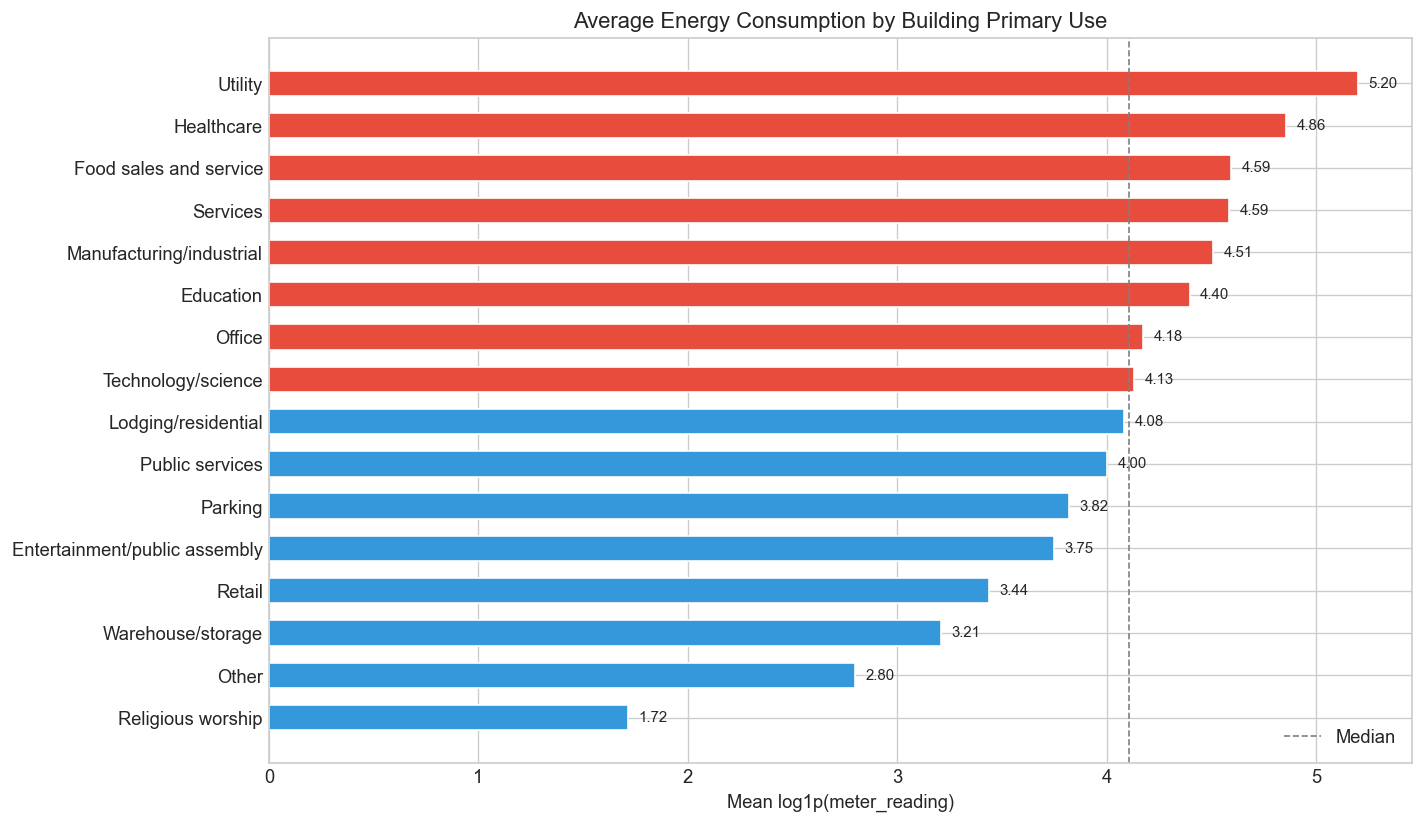

Saved → /Users/wangyu/Desktop/ASHRAE_Portfolio/outputs/figures/eda_energy_by_use.png


In [10]:
# --- Bar chart: mean energy by primary_use ---
use_energy = (
    sample_df.groupby("primary_use_name")["log_meter_reading"]
    .mean()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 7))
colours = ["#e74c3c" if v > use_energy.median() else "#3498db" for v in use_energy.values]
ax.barh(use_energy.index, use_energy.values, color=colours, edgecolor="white", height=0.6)
ax.set_xlabel("Mean log1p(meter_reading)")
ax.set_title("Average Energy Consumption by Building Primary Use")
ax.axvline(use_energy.median(), color="gray", linestyle="--", linewidth=1, label="Median")
ax.legend()

# Annotate values
for i, (name, val) in enumerate(use_energy.items()):
    ax.text(val + 0.05, i, f"{val:.2f}", va="center", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_energy_by_use.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'eda_energy_by_use.png'}")

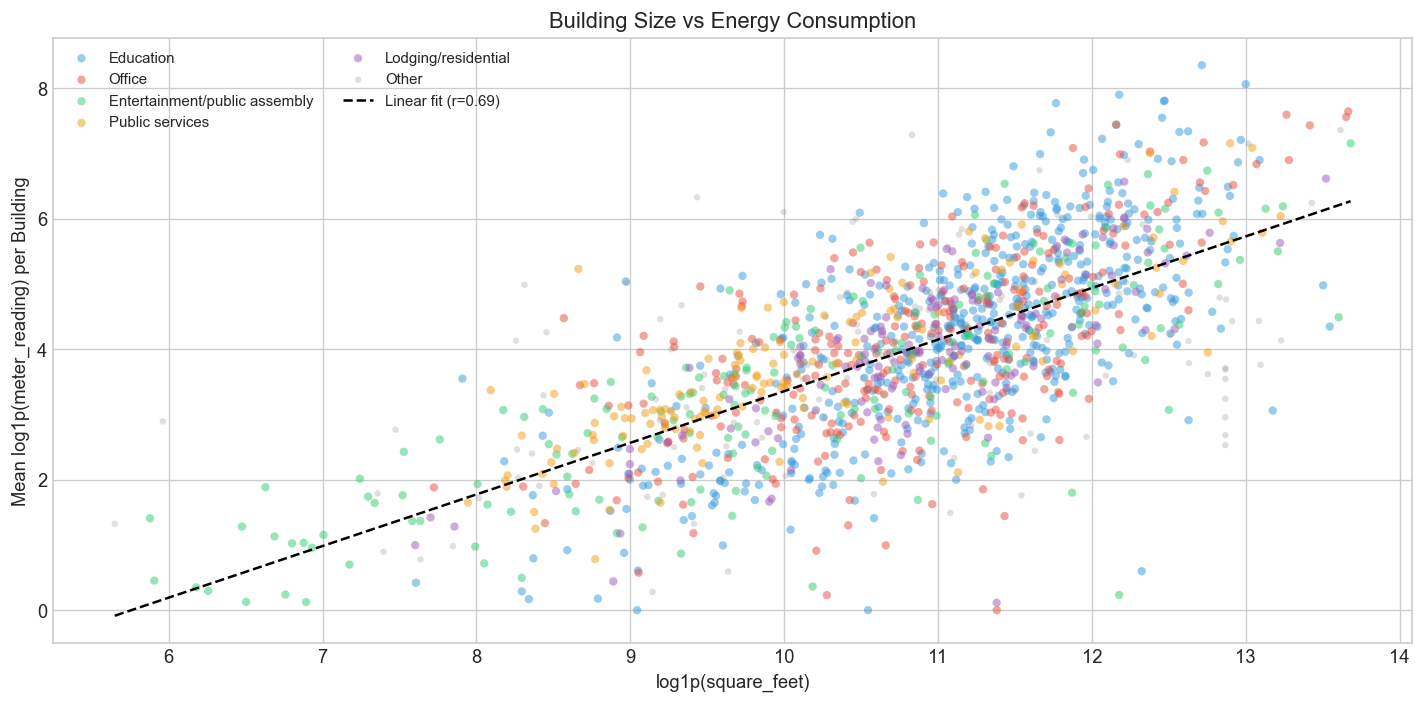

Saved → /Users/wangyu/Desktop/ASHRAE_Portfolio/outputs/figures/eda_sqft_vs_energy.png


In [11]:
# --- Scatter: log_square_feet vs mean building energy ---
building_stats = (
    sample_df.groupby("building_id")
    .agg(
        mean_energy=("log_meter_reading", "mean"),
        square_feet=("square_feet", "first"),
        primary_use_name=("primary_use_name", "first"),
    )
    .dropna(subset=["square_feet"])
)
building_stats["log_sqft"] = np.log1p(building_stats["square_feet"])

# Colour by top 5 use types, rest as gray
top_uses = building_stats["primary_use_name"].value_counts().head(5).index.tolist()
use_palette = dict(zip(top_uses, ["#3498db", "#e74c3c", "#2ecc71", "#f39c12", "#9b59b6"]))

fig, ax = plt.subplots(figsize=(12, 6))
for use in top_uses:
    sub = building_stats[building_stats["primary_use_name"] == use]
    ax.scatter(sub["log_sqft"], sub["mean_energy"],
              alpha=0.5, s=25, label=use, color=use_palette[use], edgecolors="none")

other = building_stats[~building_stats["primary_use_name"].isin(top_uses)]
ax.scatter(other["log_sqft"], other["mean_energy"],
          alpha=0.25, s=15, label="Other", color="gray", edgecolors="none")

# Trend line
z = np.polyfit(building_stats["log_sqft"], building_stats["mean_energy"], 1)
x_line = np.linspace(building_stats["log_sqft"].min(), building_stats["log_sqft"].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), "--", color="black", linewidth=1.5,
        label=f"Linear fit (r={np.corrcoef(building_stats['log_sqft'], building_stats['mean_energy'])[0,1]:.2f})")

ax.set_xlabel("log1p(square_feet)")
ax.set_ylabel("Mean log1p(meter_reading) per Building")
ax.set_title("Building Size vs Energy Consumption")
ax.legend(fontsize=9, ncol=2)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_sqft_vs_energy.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'eda_sqft_vs_energy.png'}")

**Observations:**

- The highest-consuming building types are typically **Healthcare**, **Manufacturing/industrial**, and **Technology/science** — these have energy-intensive operations (HVAC, equipment) beyond typical office loads.
- The positive correlation between `log(square_feet)` and mean energy confirms that `log_square_feet` is a justified feature. The variance-stabilising log-log relationship linearises what would otherwise be a power-law curve, improving OLS fit.
- Considerable vertical scatter at each floor area indicates that building type, weather, and operational patterns matter beyond just size.

---
## Section 6: Missing Data Summary

Understanding the missing-data pattern validates our imputation strategy in `data_preprocessing.py`. Weather columns are the primary source of missingness — temperature sensors may fail for hours or even days.

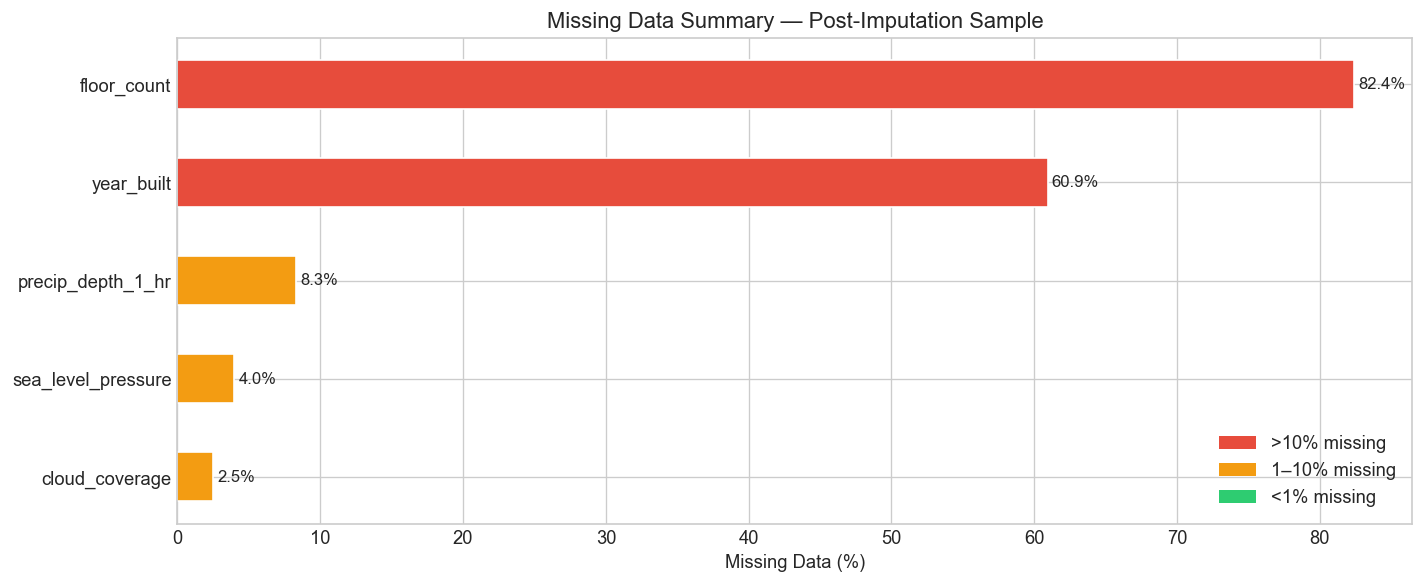

Saved → /Users/wangyu/Desktop/ASHRAE_Portfolio/outputs/figures/eda_missing_data.png


In [12]:
# --- Missing data percentage by column ---
missing_pct = (sample_df.isna().sum() / len(sample_df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]  # Only show columns with missing data

fig, ax = plt.subplots(figsize=(12, 5))

colours = ["#e74c3c" if v > 10 else "#f39c12" if v > 1 else "#2ecc71" for v in missing_pct.values]
bars = ax.barh(missing_pct.index, missing_pct.values, color=colours, edgecolor="white", height=0.5)

# Annotate percentages
for bar, val in zip(bars, missing_pct.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=10)

ax.set_xlabel("Missing Data (%)")
ax.set_title("Missing Data Summary — Post-Imputation Sample")
ax.invert_yaxis()

# Add legend for colour coding
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e74c3c", label=">10% missing"),
    Patch(facecolor="#f39c12", label="1–10% missing"),
    Patch(facecolor="#2ecc71", label="<1% missing"),
]
ax.legend(handles=legend_elements, loc="lower right")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_missing_data.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR / 'eda_missing_data.png'}")

**Imputation strategy assessment:**

- `floor_count` and `year_built` have high missingness — these are **building metadata** gaps (not sensor failures), so imputation is unreliable. In `feature_engineering.py`, `year_built` is transformed to `building_age` with NaN → 0 ("unknown age"), and `floor_count` is not used as a feature.
- `cloud_coverage` remains significantly missing even after interpolation — entire sites lacked cloud-cover sensors. LightGBM and XGBoost handle NaN natively, so this is acceptable for tree models. For the OLS notebook, these NaN will be dropped.
- `air_temperature` and `dew_temperature` — the two most important weather features — have **zero remaining NaN** after the interpolation + ffill/bfill strategy. The imputation pipeline was effective where it matters most.

---

## Summary

| Finding | Design implication |
|---|---|
| Extreme right skew in `meter_reading` | Use `log1p` target ↔ RMSLE metric |
| Distinct distributions per meter type | Include `meter` as categorical feature |
| Strong diurnal + weekly periodicity | Cyclic sin/cos encoding of hour & month |
| `air_temp` ↔ `dew_temp` correlation >0.85 | VIF concern → monitor in Notebook 02 |
| Energy scales with log(floor area) | Use `log_square_feet` feature |
| Weather NaN concentrated in 3 columns | Tree models handle natively; OLS drops NaN |

**Next:** Notebook 02 — Statistical Inference. We fit OLS on the stratified sample, test every classical assumption, and use each violation to motivate the progression to non-linear models.